In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("/Users/laingangiang/Downloads/starbucks_customer_ordering_patterns.csv")

df.rename(columns={"customer_id": "Customer ID", 
                   "order_id": "Order ID", 
                   "order_date": "Order Date", 
                   "order_time": "Order Time", 
                   "order_channel": "Order Channel", 
                   "store_id": "Store ID", 
                   "store_location_type": "Store Location Type", 
                   "region": "Region", 
                   "customer_age_group": "Customer Age Group", 
                   "customer_gender": "Customer Gender", 
                   "is_rewards_member": "Is Rewards Member",
                   "cart_size": "Cart Size", 
                   "day_of_week": "Day of Week",
                   "customer_gender": "Customer Gender",
                   "cart_size": "Cart Size",
                   "num_customizations": "Number of Customizations",
                   "total_spend": "Total Spending",
                   "drink_category": "Drink Category",
                   "fulfillment_time_min": "Fulfillment Time",
                   "customer_satisfaction": "Customer Satisfaction"}, 
                   inplace=True)
df.drop_duplicates("Order ID", inplace=True)

In [3]:
# Display dataset structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer ID               100000 non-null  object 
 1   Order ID                  100000 non-null  object 
 2   Order Date                100000 non-null  object 
 3   Order Time                100000 non-null  object 
 4   Day of Week               100000 non-null  object 
 5   Order Channel             100000 non-null  object 
 6   Store ID                  100000 non-null  object 
 7   Store Location Type       100000 non-null  object 
 8   Region                    100000 non-null  object 
 9   Customer Age Group        100000 non-null  object 
 10  Customer Gender           100000 non-null  object 
 11  Is Rewards Member         100000 non-null  bool   
 12  Cart Size                 100000 non-null  int64  
 13  Number of Customizations  100000 non-null  in

In [4]:
# Display first and last rows of dataset
print(df.head(10))
print(df.tail(10))

  Customer ID      Order ID  Order Date Order Time Day of Week  \
0  CUST_12974  ORD_00000001  2024-03-25      08:47         Mon   
1  CUST_08235  ORD_00000002  2025-07-18      08:02         Fri   
2  CUST_00393  ORD_00000003  2025-01-15      05:40         Wed   
3  CUST_06936  ORD_00000004  2024-07-30      15:10         Tue   
4  CUST_09800  ORD_00000005  2024-06-18      07:38         Tue   
5  CUST_04338  ORD_00000006  2025-08-30      11:41         Sat   
6  CUST_11185  ORD_00000007  2025-10-05      06:55         Sun   
7  CUST_00361  ORD_00000008  2025-12-17      19:08         Wed   
8  CUST_13235  ORD_00000009  2024-02-03      06:44         Sat   
9  CUST_08695  ORD_00000010  2025-05-12      12:28         Mon   

      Order Channel Store ID Store Location Type     Region  \
0        Drive-Thru  STR_340            Suburban  Southwest   
1        Mobile App  STR_425               Urban  Northeast   
2             Kiosk  STR_103            Suburban    Midwest   
3        Drive-Thru  

In [5]:
# Check for missing values
print(df.isnull().sum())

Customer ID                 0
Order ID                    0
Order Date                  0
Order Time                  0
Day of Week                 0
Order Channel               0
Store ID                    0
Store Location Type         0
Region                      0
Customer Age Group          0
Customer Gender             0
Is Rewards Member           0
Cart Size                   0
Number of Customizations    0
Total Spending              0
Fulfillment Time            0
Drink Category              0
has_food_item               0
order_ahead                 0
Customer Satisfaction       0
dtype: int64


In [6]:
# Show basic statistics of dataset
print(df.describe())

           Cart Size  Number of Customizations  Total Spending  \
count  100000.000000              100000.00000   100000.000000   
mean        3.741510                   1.81077       14.866771   
std         1.697817                   1.46280        5.506800   
min         1.000000                   0.00000        3.510000   
25%         3.000000                   1.00000       10.837500   
50%         4.000000                   2.00000       14.170000   
75%         5.000000                   3.00000       18.180000   
max        10.000000                   8.00000       40.310000   

       Fulfillment Time  Customer Satisfaction  
count     100000.000000          100000.000000  
mean           4.546080               3.687530  
std            1.550269               1.184123  
min            1.000000               1.000000  
25%            3.400000               3.000000  
50%            4.400000               4.000000  
75%            5.500000               5.000000  
max          

In [7]:
# Count orders per day of week
orders_per_day = df["Day of Week"].value_counts()
orders_per_day.index.name = "Orders per day"

print(orders_per_day)

Orders per day
Sat    14443
Mon    14386
Tue    14385
Fri    14277
Thu    14214
Sun    14175
Wed    14120
Name: count, dtype: int64


In [8]:
# Count unique customer IDs per day of week
unique_customer_count_per_day = df.groupby("Day of Week")["Customer ID"].nunique()
unique_customer_count_per_day.index.name = "Unique Customer Count per day"

print(unique_customer_count_per_day)

Unique Customer Count per day
Fri    9205
Mon    9298
Sat    9327
Sun    9263
Thu    9224
Tue    9318
Wed    9135
Name: Customer ID, dtype: int64


In [9]:
# Create pivot table
pivot_table1 = pd.concat([orders_per_day, unique_customer_count_per_day], axis=1)
pivot_table1.columns=("Order per day", "Number of Unique Customers")

print(pivot_table1)

     Order per day  Number of Unique Customers
Sat          14443                        9327
Mon          14386                        9298
Tue          14385                        9318
Fri          14277                        9205
Thu          14214                        9224
Sun          14175                        9263
Wed          14120                        9135


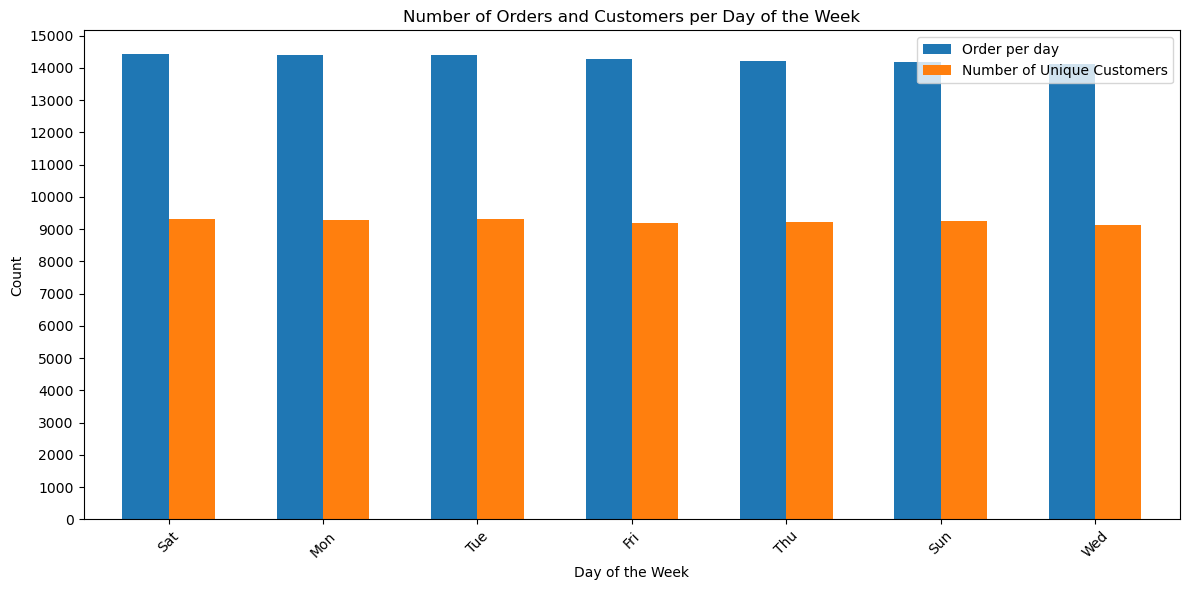

In [10]:
# Visualize orders and unique customer counts per day
y_min = pivot_table1.min().min()
y_max = pivot_table1.max().max()

pivot_table1.plot(kind="bar", width=0.6, figsize=(12, 6))
plt.title("Number of Orders and Customers per Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.yticks(np.arange(0, y_max + 1000, 1000))
plt.tight_layout()
plt.show()

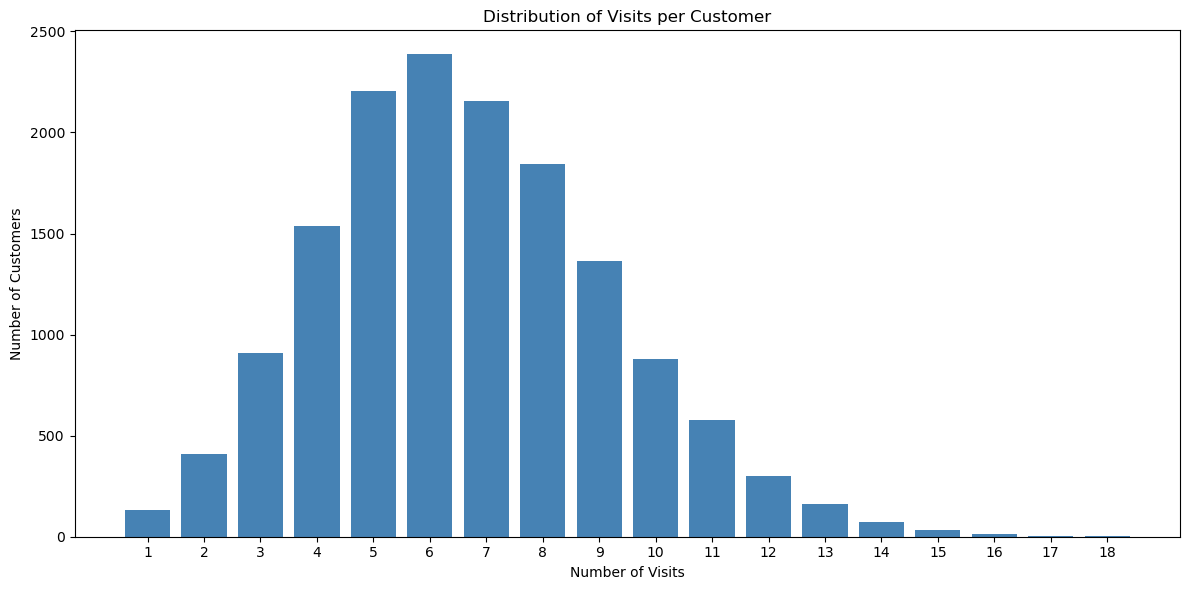

In [11]:
# Plot distribution of visits per customer
visits_per_customer = df.groupby("Customer ID")["Order ID"].nunique()
visits_per_customer.index.name = "Customer ID"
visit_distribution = visits_per_customer.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(visit_distribution.index, visit_distribution.values, color="steelblue")
plt.title("Distribution of Visits per Customer")
plt.xlabel("Number of Visits")
plt.ylabel("Number of Customers")
plt.xticks(np.arange(1, visits_per_customer.max() + 1, 1))
plt.tight_layout()
plt.show()

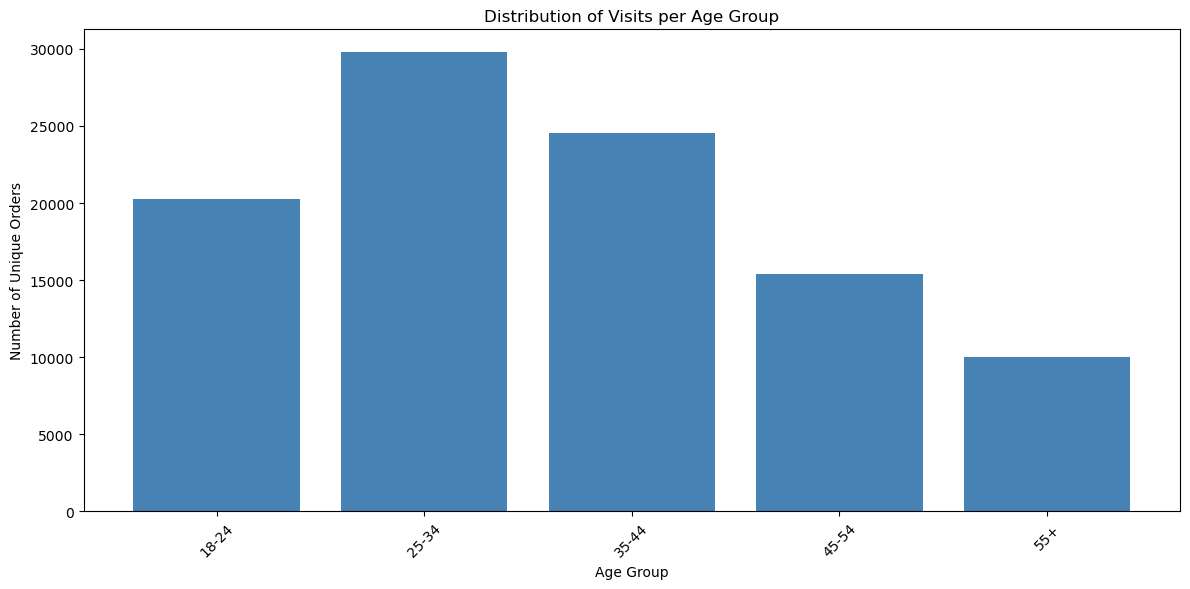

In [12]:
# Visits by age group
visits_per_age_group = df.groupby("Customer Age Group")["Order ID"].nunique().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(visits_per_age_group.index, visits_per_age_group.values, color="steelblue")
plt.title("Distribution of Visits per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Unique Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

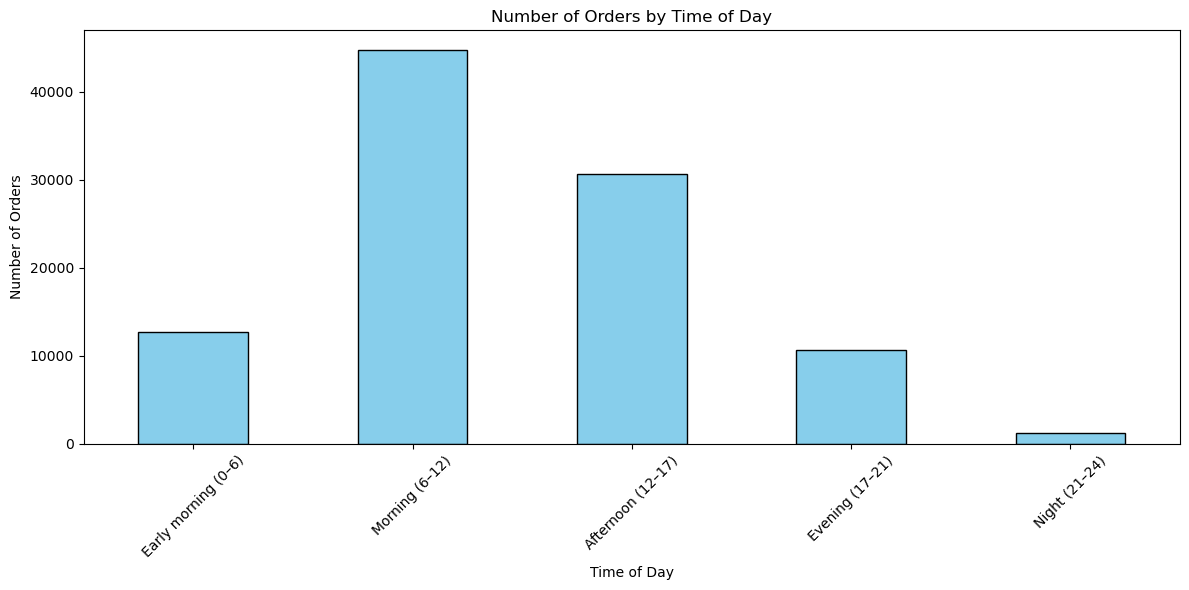

In [13]:
# Number of orders by time of day
df["Order Time"] = pd.to_datetime(df["Order Time"], format="%H:%M")
df["Hour"] = df["Order Time"].dt.hour

bins = [0, 6, 12, 17, 21, 24]
labels = ["Early morning (0–6)", "Morning (6–12)", "Afternoon (12–17)", "Evening (17–21)", "Night (21–24)"]

df["Time of order"] = pd.cut(df["Hour"], bins=bins, labels=labels, include_lowest=True)
df["Time of order"].value_counts().reindex(labels).plot(kind='bar', color='skyblue', edgecolor='black', figsize=(12, 6))

plt.title("Number of Orders by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

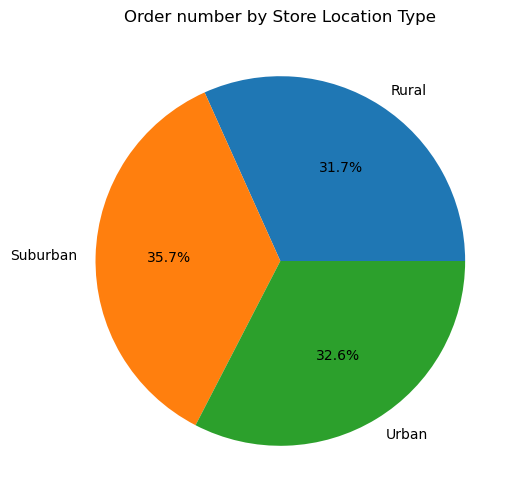

In [14]:
# Number of orders by store location type
visits_per_location_type = df.groupby("Store Location Type")["Order ID"].nunique().sort_index()
visits_per_location_type.plot(kind='pie', autopct='%1.1f%%', figsize=(12, 6))

plt.xlabel("")
plt.ylabel("")
plt.title("Order number by Store Location Type")
plt.show()

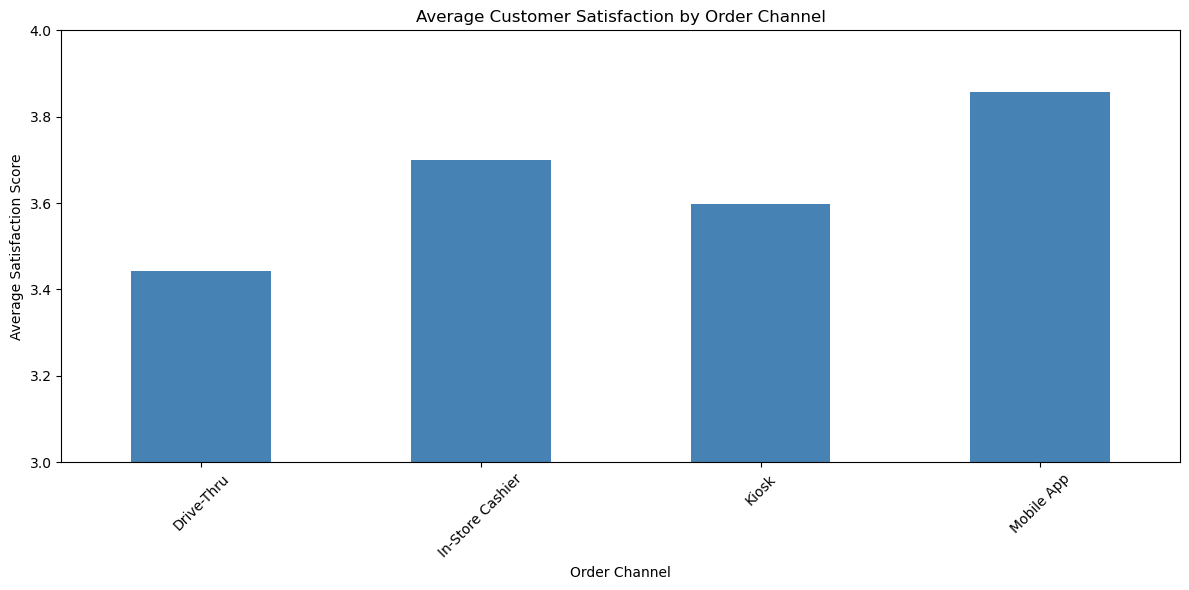

In [15]:
# Average customer satisfaction by order channel
avg_satisfaction_by_channel = df.groupby("Order Channel")["Customer Satisfaction"].mean().sort_index()

avg_satisfaction_by_channel.plot(kind="bar", figsize=(12, 6), color="steelblue")
plt.title("Average Customer Satisfaction by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Satisfaction Score")
plt.xticks(rotation=45)
plt.ylim(3, 4)
plt.tight_layout()
plt.show()

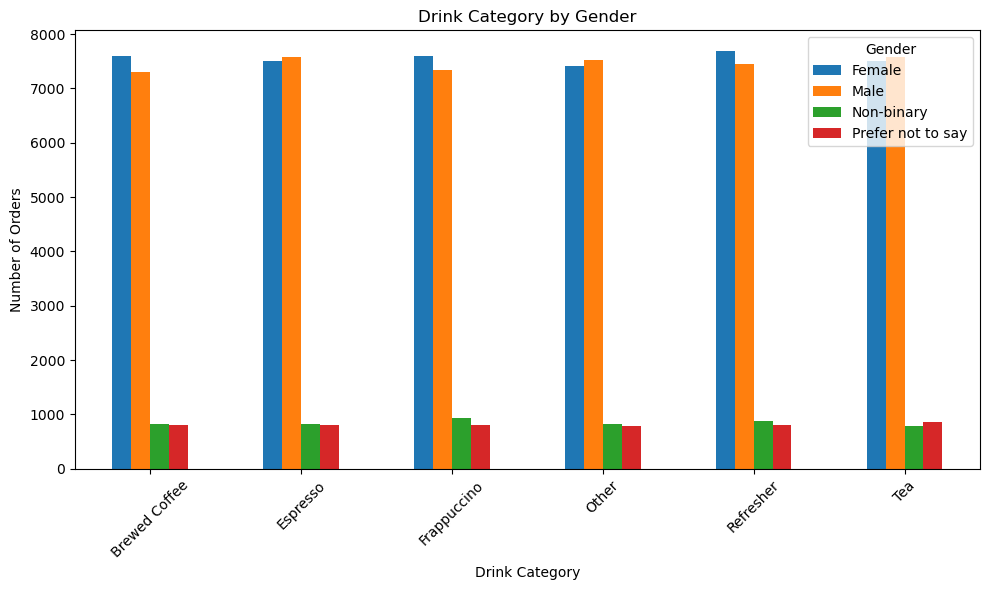

In [16]:
# Drink category by customer gender
drink_cat_by_gender = pd.crosstab(df["Drink Category"], df["Customer Gender"])
drink_cat_by_gender.plot(kind="bar", figsize=(10, 6))

plt.title("Drink Category by Gender")
plt.xlabel("Drink Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

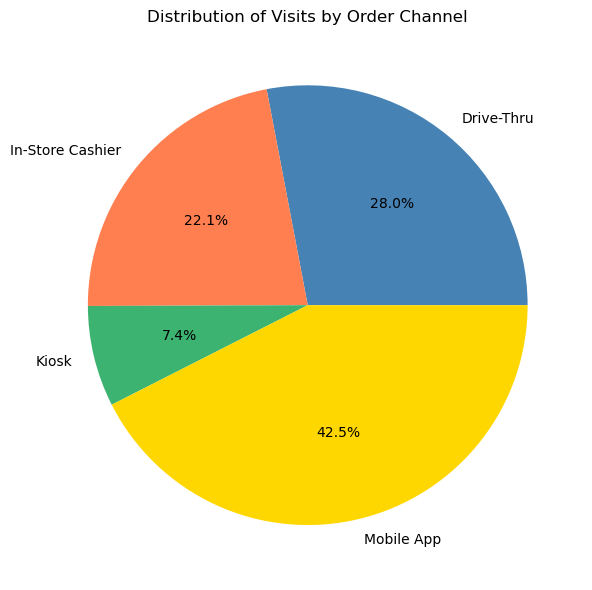

In [17]:
# Distribution of visits by order channel
visits_per_ord_channel = df.groupby("Order Channel")["Order ID"].nunique().sort_index()

plt.figure(figsize=(10, 6))
plt.pie(visits_per_ord_channel.values, labels=visits_per_ord_channel.index, colors=["steelblue", "coral", "mediumseagreen", "gold"], autopct="%1.1f%%")
plt.title("Distribution of Visits by Order Channel")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

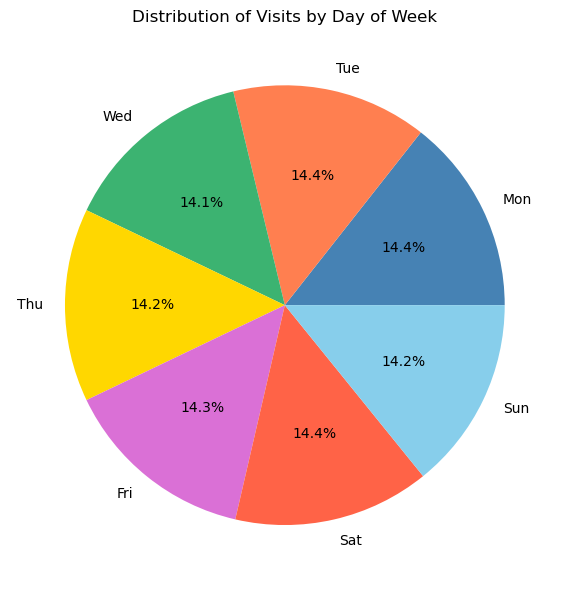

In [18]:
# Distribution of visits by day of week
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
visits_per_day = orders_per_day.reindex(day_order)
colors = ["steelblue", "coral", "mediumseagreen", "gold", "orchid", "tomato", "skyblue"]

plt.figure(figsize=(10, 6))
plt.pie(visits_per_day.values, labels=visits_per_day.index, colors=colors, autopct="%1.1f%%")
plt.title("Distribution of Visits by Day of Week")
plt.tight_layout()
plt.show()